## Regular water waves interacting with a porous semi-circular obstacle - Frequency-Domain BEM

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D BEM to simulate the propagation of regular linear water waves interacting with a porous semi-circular obstacle.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave structure interaction problem
- Analyse the effect of the mesh refinement on the results
- Compute wave reflection and transmission coefficients
- Compute the force components

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from MAIN_MESH_SEMI_CIRC import MAIN_MESH_SEMI_CIRC
    
from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR
from BEM_UTILS.MATCHING import MATCHING

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from BEM_UTILS.FORCE import FORCE

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.ENERGY_FLUX import ENERGY_FLUX
from BEM_UTILS.NODES_FS import NODES_FS
from BEM_UTILS.POROUS_NODES import POROUS_NODES

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_IN import FLUXES_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_OUT import FLUXES_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.BC_CONSTANT_G import BC_CONSTANT_G
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

**2.1 Physical domain and geometry parameters**

In [2]:
# FLUID DOMAIN
DEPTH         = 0.50;
WIDTH_CHANNEL = 0.10*DEPTH;
LX = 3.00*DEPTH;

# Structure geometry
RADIUS   = 0.25;
N_STRUCT = 1;

# Numerical model
NUM_OF_REG = 2;

In [3]:
# GMSH mesh
MAIN_MESH_SEMI_CIRC(DEPTH,RADIUS,WIDTH_CHANNEL,LX)

**2.2 Wave parameters and frequency range**

In [4]:
# Number of frequencies / wave cases
ttmax = 20

# Dimensionless wavenumber (k*h)
kh = np.linspace(0.005, 3.00, ttmax)

# Wave steepness H/λ
HL = 0.01

# Porous effect parameter
G_ori = 0.50

**3. Mesh**

In [5]:
# Read the Gmsh file and extract node PROCESS_CONNECTIVITY and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("SEMI_CIRCULAR_OUTER.msh")
MESH_1_POS, MESH_1_QUADS9 = PROCESS_MESH("SEMI_CIRCULAR_INNER.msh")

In [6]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [7]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)
N[1] ,  NE[1] ,  KCONEC_1 = PROCESS_CONNECTIVITY(MESH_1_POS , MESH_1_QUADS9)

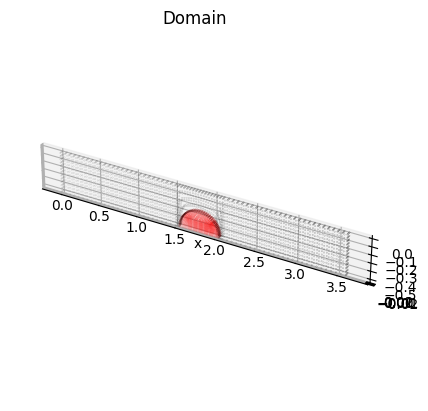

In [9]:
# Domain visulization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=0.01
)

ax.scatter(
    MESH_1_POS[:,0],
    MESH_1_POS[:,1],
    MESH_1_POS[:,2],
    c='r',
    s=0.01
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_0_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [10]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)
REF_R1 , NORMAL_1 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_1 , MESH_1_POS , NE[1], N_STRUCT)

In [11]:
# Concatenate normal array
NORMAL = np.vstack((NORMAL_0, NORMAL_1))

In [12]:
# Match central nodes (the 9th node) between adjacent regions to define the interface connectivity
# Semi-circle
NODES_MATCH_CYL = MATCHING(REF_R0['POROUS'] ,  MESH_0_POS  ,  KCONEC_0  ,  REF_R1['POROUS'] ,  MESH_1_POS  ,  KCONEC_1);

In [13]:
# Total number of nodes and elements
N_total  = np.sum(N)
NE_total = np.sum(NE)

In [14]:
# Concatenate local connectivity matrices and map local node indices to the global coordinate system
KCON_N_0  = KCONEC_0
KCON_N_01 = KCONEC_1 + N[0]

KCONEC = np.hstack((KCON_N_0, KCON_N_01))

**4. Influence matrices**

In [15]:
# Form H and B matrices for each region
H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);
H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC_1 , NE[1] , N[1] , DEPTH);

In [16]:
# Assembling the H and G matrices
from scipy.linalg import block_diag
H = np.zeros((N_total, N_total), dtype=np.complex128)

H = block_diag(H0, H1)

G = np.zeros((N_total, NCONEC * NE_total), dtype=np.complex128)

G = block_diag(G0, G1)

In [17]:
# Identify matching nodes across interfaces. 
# Provides a mapping of local node indices, element indices, and local ordering (1-9).
# Note: STORE_NODE_out and STORE_NODE_in maintain a 1-to-1 row correspondence.
[STORE_NODE_R0_CYL, STORE_NODE_R1_CYL] = POROUS_NODES(NCONEC, KCONEC_0, KCONEC_1, MESH_0_POS, MESH_1_POS, NODES_MATCH_CYL);

**5. Frequency loop and boundary condition application**

In [18]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

# Preallocate arrays for force components
FX_1 = np.zeros(ttmax,dtype=complex)
FY_1 = np.zeros(ttmax,dtype=complex)
FZ_1 = np.zeros(ttmax,dtype=complex)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN(A, B, k, NCONEC,  NORMAL, REF_R0["IN"],  KCONEC, NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NCONEC, NORMAL, REF_R0["OUT"], KCONEC, NE, 0)

    # Porous boundary condition
    Gporous   = G_ori/(k*DEPTH);
    A = BC_CONSTANT_G(A, B, k, NCONEC, STORE_NODE_R0_CYL, STORE_NODE_R1_CYL, N, NE, Gporous, 0, 1)
    
    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC[0:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Incident wave energy flux   
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes    
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R0["OUT"], MESH_0_POS,
        KCONEC,
        N, NE, 0, 0)

    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)
    
    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]      

    # Force components
    FX_1[tt], FY_1[tt], FZ_1[tt] = FORCE(Coef_S, MESH_1_POS, NCONEC, REF_R1["POROUS"], KCONEC, N, NE, 1) 
      
# END LOOPS

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


**6. Results**

**6.1 Energy coeffcients**

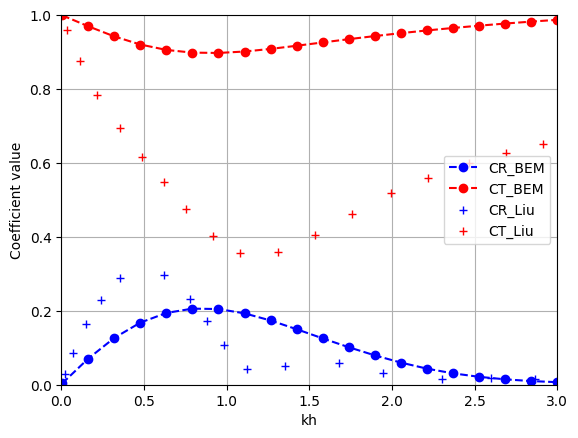

In [19]:
# Validation with: Analysis of wave interaction with submerged perforated semi-circular breakwaters through multipole method Yong Liu∗, Hua-Jun Li
CR_Liu = np.array([
    [0.0247, 0.0285], [0.0711, 0.0864], [0.1522, 0.1640], [0.2391, 0.2303],
    [0.3576, 0.2894], [0.6231, 0.2981], [0.7785, 0.2310], [0.8792, 0.1714],
    [0.9856, 0.1084], [1.1209, 0.0433], [1.3546, 0.0500], [1.6806, 0.0579],
    [1.9487, 0.0318], [2.3006, 0.0145], [2.5977, 0.0186], [2.8659, 0.0164]
])

CT_Liu = np.array([
    [0.0345, 0.9589], [0.1122, 0.8766], [0.2186, 0.7846], [0.3538, 0.6939],
    [0.4890, 0.6165], [0.6184, 0.5474], [0.7565, 0.4749], [0.9147, 0.4017],
    [1.0786, 0.3570], [1.3116, 0.3597], [1.5360, 0.4056], [1.7574, 0.4619],
    [1.9962, 0.5175], [2.2176, 0.5599], [2.4679, 0.5989], [2.6922, 0.6280],
    [2.9108, 0.6523]
])

plt.figure(15)

plt.plot(kh, CR, 'b--o', label='CR_BEM')
plt.plot(kh, CT, 'r--o', label='CT_BEM')

plt.plot(CR_Liu[:,0], CR_Liu[:,1], 'b+', label='CR_Liu')
plt.plot(CT_Liu[:,0], CT_Liu[:,1], 'r+', label='CT_Liu')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

# Optional: display the plot
plt.show()

**6.2 Force components**

<Figure size 640x480 with 0 Axes>

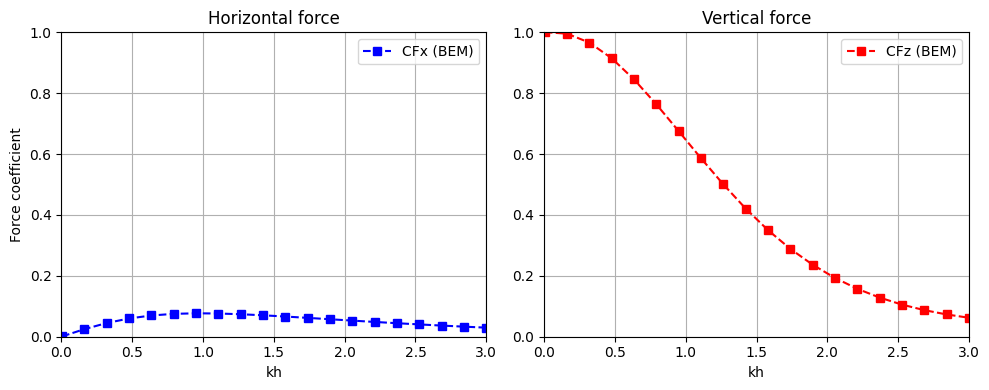

In [21]:
# Validation with: Analysis of wave interaction with submerged perforated semi-circular breakwaters through multipole method Yong Liu∗, Hua-Jun Li

plt.figure(100)

TERM = (rho*gravity*2*WAVE["Amp"]*RADIUS*WIDTH_CHANNEL)

CFX = np.abs(1j*rho*WAVE["omega"]*(FX_1))/TERM
CFZ = np.abs(1j*rho*WAVE["omega"]*(FZ_1))/TERM

# Create figure with 2 plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# --- Horizontal force ---
ax1.plot(kh, CFX, 'b--s', label='CFx (BEM)')
ax1.set_xlim([0,3])
ax1.set_ylim([0,1.0])
ax1.set_xlabel('kh')
ax1.set_ylabel('Force coefficient')
ax1.set_title('Horizontal force')
ax1.grid(True)
ax1.legend()

# --- Vertical force ---
ax2.plot(kh, CFZ, 'r--s', label='CFz (BEM)')
ax2.set_xlim([0,3])
ax2.set_ylim([0,1.0])
ax2.set_xlabel('kh')
ax2.set_title('Vertical force')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("FX_FZ_side_by_side.pdf")
plt.show()